In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/review_intelligence'
os.chdir(PROJECT_ROOT)
print("✅ Ready to work!")

Mounted at /content/drive
✅ Ready to work!


In [2]:
!pip install -q transformers torch sentence-transformers

import pandas as pd
import numpy as np
from transformers import pipeline
import re
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
df = pd.read_csv('data/processed/amazon_reviews_cleaned.csv')

print(f"✅ Loaded {len(df):,} cleaned reviews")
print(f"Columns available: {df.columns.tolist()}")

✅ Loaded 5,000 cleaned reviews
Columns available: ['sentiment_label', 'review_title', 'text', 'rating', 'text_for_models', 'text_for_stats']


In [4]:
def extract_noun_phrases(text):
    """
    Extracts noun phrases from a piece of text using POS tagging.

    A noun phrase in our grammar pattern is:
    - An optional adjective (JJ) followed by one or more nouns (NN, NNS)
    - This captures things like "battery life", "poor quality", "sound quality"

    We use a simple grammar rule rather than a full parser because
    we want speed over perfect linguistic accuracy here.
    """
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)

    noun_phrases = []
    current_phrase = []

    for word, tag in pos_tags:
        # Build phrases by collecting adjectives followed by nouns
        if tag in ('JJ', 'JJR', 'JJS'):      # adjective — could start a phrase
            current_phrase = [word]
        elif tag in ('NN', 'NNS', 'NNP', 'NNPS'):   # noun — part of a phrase
            current_phrase.append(word)
        else:
            # When we hit a non-adjective/non-noun word, save the phrase
            if len(current_phrase) >= 1:
                # Only save phrases that contain at least one noun
                # Filter out single stopwords masquerading as noun phrases
                phrase = ' '.join(current_phrase)
                if len(phrase) > 3:    # ignore very short phrases
                    noun_phrases.append(phrase)
            current_phrase = []

    return noun_phrases


# Testing
test_reviews = [
    "i bought both the battery grip armor and the camera armor for my nikon d200",
    "the sound quality is amazing but the battery life is terrible",
    "poor build quality and the customer service was completely unhelpful"
]

print("=== NOUN PHRASE EXTRACTION TEST ===\n")
for review in test_reviews:
    phrases = extract_noun_phrases(review)
    print(f"Review: {review[:80]}")
    print(f"Phrases found: {phrases}\n")

=== NOUN PHRASE EXTRACTION TEST ===

Review: i bought both the battery grip armor and the camera armor for my nikon d200
Phrases found: ['battery grip armor', 'camera armor']

Review: the sound quality is amazing but the battery life is terrible
Phrases found: ['sound quality', 'battery life']

Review: poor build quality and the customer service was completely unhelpful
Phrases found: ['poor', 'quality', 'customer service']



In [5]:

print("⏳ Extracting noun phrases from all reviews (may take 2-3 minutes)...")

all_phrases = []

# We use text_for_models because it has clean lowercased text
# but still preserves the natural word forms that POS tagging needs
for text in df['text_for_models']:
    if pd.notna(text) and len(str(text)) > 10:
        phrases = extract_noun_phrases(str(text))
        all_phrases.extend(phrases)

print(f"✅ Extracted {len(all_phrases):,} total noun phrases")

phrase_freq = Counter(all_phrases)
top_phrases = phrase_freq.most_common(50)


⏳ Extracting noun phrases from all reviews (may take 2-3 minutes)...
✅ Extracted 80,895 total noun phrases


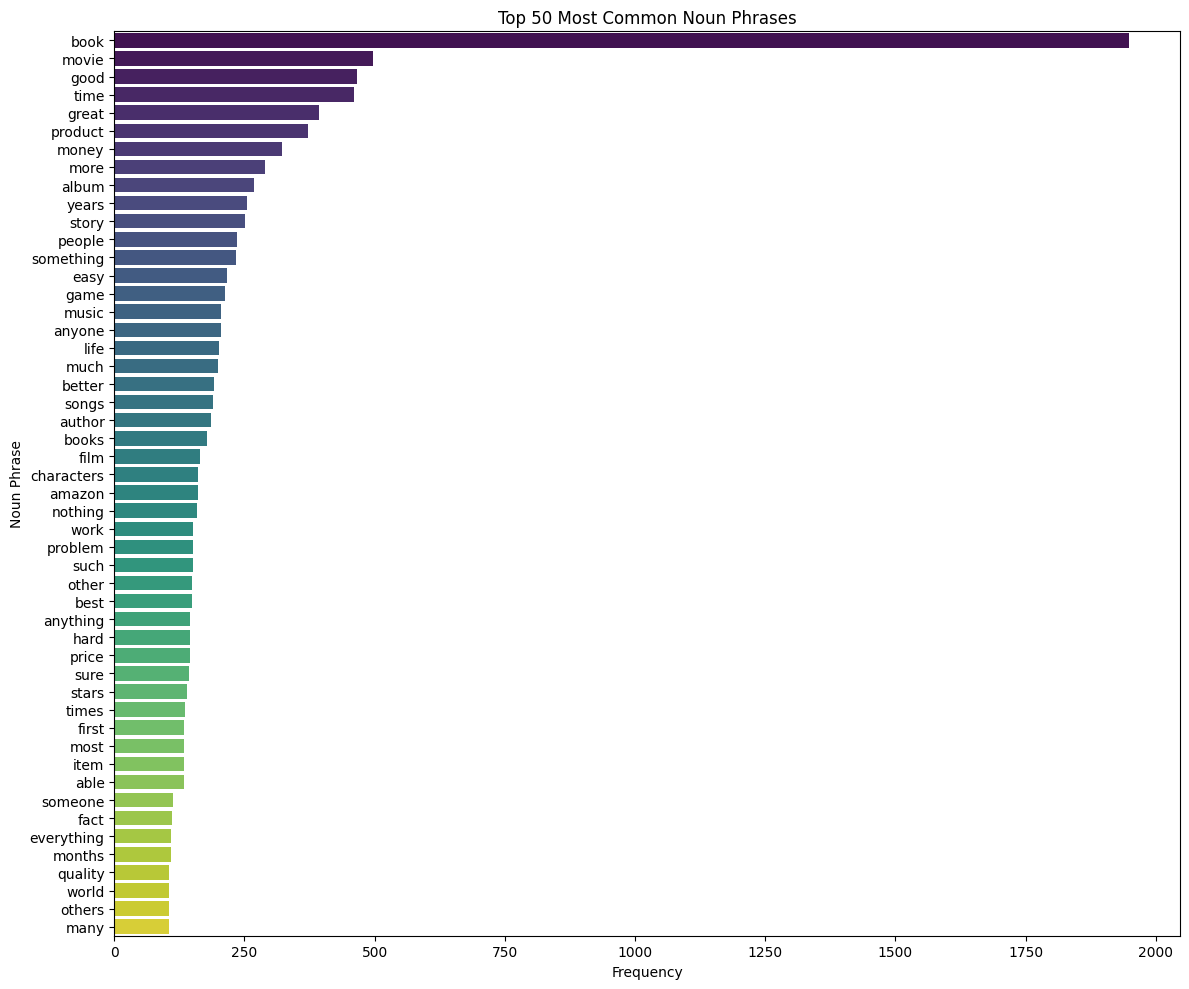

In [6]:
import seaborn as sns

phrases_df = pd.DataFrame(top_phrases, columns=['Phrase', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Phrase', data=phrases_df, palette='viridis')
plt.title('Top 50 Most Common Noun Phrases')
plt.xlabel('Frequency')
plt.ylabel('Noun Phrase')
plt.tight_layout()
plt.show()

In [7]:
ASPECT_TAXONOMY = {
    "product quality": [
        "the physical quality, durability, and build of a tangible product, "
        "whether materials feel premium or cheap, how well something is constructed, "
        "whether it broke or fell apart, manufacturing defects"
    ],
    "value for money": [
        "whether the price is fair or too expensive, whether the purchase was worth "
        "the cost, feeling ripped off or getting a good deal, pricing complaints, "
        "refund requests, not worth the money"
    ],
    "functionality": [
        "whether a physical product or software works correctly and as advertised, "
        "technical performance, features that do not work, malfunctions, "
        "ease of use for a device or tool, setup difficulty, connectivity problems"
    ],
    "customer experience": [
        "shipping speed, delivery problems, packaging damage, seller communication, "
        "customer support quality, return and refund process, order fulfillment"
    ],
    "content quality": [
        "the quality of written, audio, or visual content — for books: writing style, "
        "story, plot, characters, narrative; for music: sound quality, composition, "
        "performance; for movies and shows: acting, directing, story, entertainment value; "
        "for educational content: accuracy, depth, usefulness of information"
    ],
    "design and aesthetics": [
        "the physical visual design of a tangible product — its shape, color, size, "
        "appearance, how it looks on a shelf or in a room, packaging design, "
        "whether it looks attractive or ugly as a physical object you can hold"
    ]
}

# 1. We use "Expanded Labels" - short enough to be grammatical, descriptive enough to be accurate
optimized_aspects = {
    "product quality": "product build and material quality",
    "value for money": "pricing and value for money",
    "functionality": "battery life, performance, and functionality",
    "customer experience": "shipping, delivery, packaging, and customer service", # Refined description
    "content quality": "quality of story, writing, film, or music", # Refined description
    "design and aesthetics": "visual design and aesthetics"
}

In [8]:
print("⏳ Loading zero-shot classification model...")
print("This downloads ~270MB on first run, then loads from cache...")

# We use this specific model because it is:
# 1. Lightweight enough to run on Colab's free GPU
# 2. Specifically fine-tuned for Natural Language Inference (NLI)
#    which is the task of deciding if text A is related to description B
# 3. Produces reliable confidence scores we can threshold

classifier = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-MiniLM2-L6-H768",
    device=0 if __import__('torch').cuda.is_available() else -1
    # device=0 means use GPU if available, -1 means use CPU
)

print("✅ Model loaded successfully!")

test_text = "received mine yesterday from amazon and can confirm it is the remaster. looked stunning, sounded stunning - and my son came away from his first viewing ever of this masterpiece with a simple, one-word "'wow'" wow indeed boy."

# Extract just the values (the expanded labels)
candidate_labels = list(optimized_aspects.values())

result = classifier(
    test_text,
    candidate_labels=candidate_labels,
    multi_label=True,
    hypothesis_template="This review discusses {}."
)

reverse_taxonomy = {expanded: short for short, expanded in optimized_aspects.items()}

print("\n=== REVISED MODEL TEST ===")
print(f"Review: '{test_text}'")
print("\nAspect scores:")

for label, score in zip(result['labels'], result['scores']):
    short_name = reverse_taxonomy[label]
    bar = "█" * int(score * 20)
    print(f"  {short_name:<25} {score:.3f} {bar}")

⏳ Loading zero-shot classification model...
This downloads ~270MB on first run, then loads from cache...


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Model loaded successfully!

=== REVISED MODEL TEST ===
Review: 'received mine yesterday from amazon and can confirm it is the remaster. looked stunning, sounded stunning - and my son came away from his first viewing ever of this masterpiece with a simple, one-word wow wow indeed boy.'

Aspect scores:
  design and aesthetics     0.987 ███████████████████
  product quality           0.813 ████████████████
  content quality           0.562 ███████████
  value for money           0.318 ██████
  functionality             0.270 █████
  customer experience       0.034 


In [9]:
def extract_aspects_from_review(text, taxonomy=optimized_aspects):
    """
    Takes a single cleaned review and returns which aspects it discusses,
    along with the model's confidence score for each detected aspect.

    Returns a dictionary like:
    {"product quality": 0.82, "functionality": 0.71}
    """
    if not text or len(str(text).split()) < 4:
        return {}

    aspect_names = list(taxonomy.keys())
    # Corrected: Use the full descriptive labels from the taxonomy values
    aspect_descriptions = list(taxonomy.values())

    try:
        result = classifier(
            str(text)[:512],
            candidate_labels=aspect_descriptions,
            multi_label=True,
            hypothesis_template="This review discusses {}."
        )

        reverse_taxonomy = {expanded: short for short, expanded in optimized_aspects.items()}
        detected_aspects_with_scores = {}

        for label, score in zip(result['labels'], result['scores']):
            short_name = reverse_taxonomy[label]
            # Only consider aspects with a score above a certain threshold if needed, for now we add all.
            detected_aspects_with_scores[short_name] = score
            bar = "█" * int(score * 20)
            print(f"  {short_name:<25} {score:.3f} {bar}")

        return detected_aspects_with_scores

    except Exception as e:
        # print(f"Error processing text: {text} - {e}") # Uncomment for debugging
        return {}


test_cases = [
    "the sound quality is incredible but the battery only lasts 3 hours",
    "terrible book, poorly written, complete waste of money",
    "arrived two weeks late and the packaging was completely destroyed",
    "works exactly as described, great value for the price"
]

print("=== ASPECT EXTRACTION TESTS ===\n")
for review in test_cases:
    aspects = extract_aspects_from_review(review)
    print(f"Review: '{review[:70]}'")
    print(f"Aspects: {aspects}\n")

=== ASPECT EXTRACTION TESTS ===

  functionality             0.953 ███████████████████
  product quality           0.694 █████████████
  content quality           0.391 ███████
  value for money           0.095 █
  customer experience       0.002 
  design and aesthetics     0.002 
Review: 'the sound quality is incredible but the battery only lasts 3 hours'
Aspects: {'functionality': 0.9531448483467102, 'product quality': 0.6944016814231873, 'content quality': 0.3910290598869324, 'value for money': 0.09549371898174286, 'customer experience': 0.0023596426472067833, 'design and aesthetics': 0.0017634860705584288}

  value for money           0.019 
  product quality           0.015 
  content quality           0.008 
  customer experience       0.001 
  design and aesthetics     0.001 
  functionality             0.000 
Review: 'terrible book, poorly written, complete waste of money'
Aspects: {'value for money': 0.019217772409319878, 'product quality': 0.014726257883012295, 'content qual

In [10]:
from tqdm import tqdm

print("⏳ Running aspect extraction on all reviews...")
print("Expected time: 10-15 minutes on Colab GPU, 30-40 mins on CPU\n")

aspect_results = []

for text in tqdm(df['text_for_models'], desc="Extracting aspects"):
    aspects = extract_aspects_from_review(str(text))
    aspect_results.append(aspects)

df['detected_aspects'] = aspect_results

reviews_with_aspects = df['detected_aspects'].apply(lambda x: len(x) > 0).sum()
print(f"\n✅ Aspect extraction complete!")
print(f"Reviews with at least one aspect detected: {reviews_with_aspects:,} "
      f"({reviews_with_aspects/len(df)*100:.1f}%)")

⏳ Running aspect extraction on all reviews...
Expected time: 10-15 minutes on Colab GPU, 30-40 mins on CPU



Extracting aspects:   0%|          | 1/5000 [00:01<2:01:03,  1.45s/it]

  design and aesthetics     0.968 ███████████████████
  content quality           0.891 █████████████████
  product quality           0.259 █████
  functionality             0.015 
  value for money           0.011 
  customer experience       0.000 


Extracting aspects:   0%|          | 2/5000 [00:03<2:07:31,  1.53s/it]

  content quality           0.858 █████████████████
  product quality           0.485 █████████
  value for money           0.010 
  design and aesthetics     0.004 
  functionality             0.002 
  customer experience       0.001 


...

Extracting aspects:   9%|▉         | 441/5000 [10:28<2:13:13,  1.75s/it]

  value for money           0.443 ████████
  functionality             0.366 ███████
  product quality           0.225 ████
  design and aesthetics     0.158 ███
  content quality           0.141 ██
  customer experience       0.047 


Extracting aspects:   9%|▉         | 442/5000 [10:30<1:48:20,  1.43s/it]

  content quality           0.666 █████████████
  design and aesthetics     0.209 ████
  value for money           0.180 ███
  functionality             0.048 
  product quality           0.047 
  customer experience       0.003 


KeyboardInterrupt: 

In [ ]:
aspect_counts = defaultdict(int)

for aspects in df['detected_aspects']:
    for aspect_name in aspects.keys():
        aspect_counts[aspect_name] += 1

aspect_df = pd.DataFrame(
    list(aspect_counts.items()),
    columns=['Aspect', 'Review Count']
).sort_values('Review Count', ascending=False)

aspect_df['Percentage of Reviews'] = (
    aspect_df['Review Count'] / len(df) * 100
).round(1)

print("=== ASPECT FREQUENCY ACROSS ALL REVIEWS ===\n")
print(aspect_df.to_string(index=False))

plt.figure(figsize=(10, 6))
bars = plt.barh(
    aspect_df['Aspect'][::-1],
    aspect_df['Review Count'][::-1],
    color='steelblue',
    edgecolor='white'
)
plt.title("Which Product Aspects Are Discussed Most?",
          fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews Mentioning This Aspect")

for bar, count in zip(bars, aspect_df['Review Count'][::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/aspect_distribution.png', dpi=150)
plt.show()

In [ ]:
df.to_csv('data/processed/amazon_reviews_with_aspects.csv', index=False)
print("✅ Saved to Drive with aspect columns")